# Student Performance Analysis Report

This notebook presents a structured workflow for data analysis:
1. Data loading and preparation
2. Data review
3. Exploratory analysis
4. Hypothesis testing
5. Final conclusions


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 1. Data Loading and Preparation

This section loads the dataset and prepares it for analysis.

In [2]:
df = pd.read_csv("data/Scores.csv", sep=";")
df.head()

,Unnamed: 0,student_id,gender,parental.level.of.education,subject,score
0,1,id_001,female,high school,math,23
1,2,id_001,female,high school,language,40
2,3,id_002,female,high school,math,68
3,4,id_002,female,high school,language,"80,5"
4,5,id_003,male,high school,math,82


In [3]:
df.columns = df.columns.str.lower().str.replace(" ", "_").str.replace(".", "_")
df.columns.tolist()

['unnamed:_0',
 'student_id',
 'gender',
 'parental_level_of_education',
 'subject',
 'score']

In [4]:
df = df.drop(columns=["unnamed:_0"])

In [5]:
df.describe()

,student_id,gender,parental_level_of_education,subject,score
count,972,972,972,972,972
unique,486,2,4,2,133
top,id_001,female,associate's degree,math,65
freq,2,490,354,486,26


In [6]:
df['score'] = df['score'].astype(str).str.replace(',', '.')
df['score'] = pd.to_numeric(df['score'])

In [7]:
df.head()

,student_id,gender,parental_level_of_education,subject,score
0,id_001,female,high school,math,23.0
1,id_001,female,high school,language,40.0
2,id_002,female,high school,math,68.0
3,id_002,female,high school,language,80.5
4,id_003,male,high school,math,82.0


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 972 entries, 0 to 971
Data columns (total 5 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   student_id                   972 non-null    str    
 1   gender                       972 non-null    str    
 2   parental_level_of_education  972 non-null    str    
 3   subject                      972 non-null    str    
 4   score                        972 non-null    float64
dtypes: float64(1), str(4)
memory usage: 38.1 KB


In [9]:
df.groupby('subject')['score'].describe()

,count,mean,std,min,25%,50%,75%,max
subject,,,,,,,,
language,486.0,69.001029,14.446257,19.5,58.0,70.0,78.50,100.0
math,486.0,66.380658,15.054580,23.0,56.0,66.0,77.75,100.0


## 2. Data Review

Below is a summary of the dataset and its structure.

## 2.1 Data Structure

The dataset is organized in long format, where each student has two observations — one for mathematics and one for language.

In [10]:
df['subject'].value_counts()

subject
math        486
language    486
Name: count, dtype: int64

In [11]:
df['gender'].value_counts()

gender
female    490
male      482
Name: count, dtype: int64

In [12]:
df['parental_level_of_education'].value_counts()

parental_level_of_education
associate's degree    354
high school           312
bachelor's degree     188
master's degree       118
Name: count, dtype: int64

The dataset is structured in long format, where each student contributes multiple observations depending on the subject.
This structure is appropriate for grouped statistical analysis.

# 3. Exploratory Analysis

This section compares score distributions across subjects, gender, and parental education level.

In [13]:
math_df = df[df['subject'] == 'math']
lang_df = df[df['subject'] == 'language']

In [35]:
math_df.describe(include="all")

,student_id,gender,parental_level_of_education,subject,score
count,486,486,486,486,486.000000
unique,486,2,4,1,NaN
top,id_001,female,associate's degree,math,NaN
freq,1,245,177,486,NaN
mean,NaN,NaN,NaN,NaN,66.380658
std,NaN,NaN,NaN,NaN,15.054580
min,NaN,NaN,NaN,NaN,23.000000
25%,NaN,NaN,NaN,NaN,56.000000
50%,NaN,NaN,NaN,NaN,66.000000
75%,NaN,NaN,NaN,NaN,77.750000


In [36]:
lang_df.describe(include="all")

,student_id,gender,parental_level_of_education,subject,score
count,486,486,486,486,486.000000
unique,486,2,4,1,NaN
top,id_001,female,associate's degree,language,NaN
freq,1,245,177,486,NaN
mean,NaN,NaN,NaN,NaN,69.001029
std,NaN,NaN,NaN,NaN,14.446257
min,NaN,NaN,NaN,NaN,19.500000
25%,NaN,NaN,NaN,NaN,58.000000
50%,NaN,NaN,NaN,NaN,70.000000
75%,NaN,NaN,NaN,NaN,78.500000


The descriptive statistics show differences in central tendency and dispersion between Mathematics and Language scores.

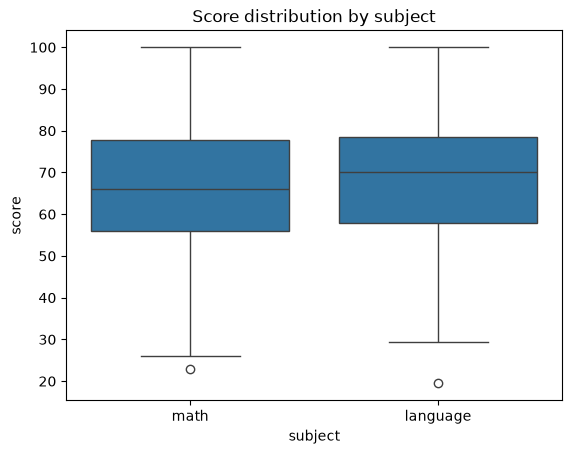

In [16]:
sns.boxplot(data=df, x="subject", y="score")
plt.title("Score distribution by subject")
plt.show()

The boxplot visualizes the distribution of scores across both subjects and allows comparison of medians and variability.

To investigate potential gender differences, descriptive statistics were computed separately for each subject.

## 3.1 Comparison of Scores by Gender

The goal of this section is to determine whether average scores differ between male and female.

In [42]:
gender_summary = (
    df.groupby(['gender', 'subject'])['score']
      .agg(['count', 'mean', 'std', 'median'])
)

gender_summary

count       mean        std  median
gender subject                                      
female language    245  73.004082  14.012508    73.0
       math        245  63.857143  15.261921    64.0
male   language    241  64.931535  13.752291    65.5
       math        241  68.946058  14.425137    70.0

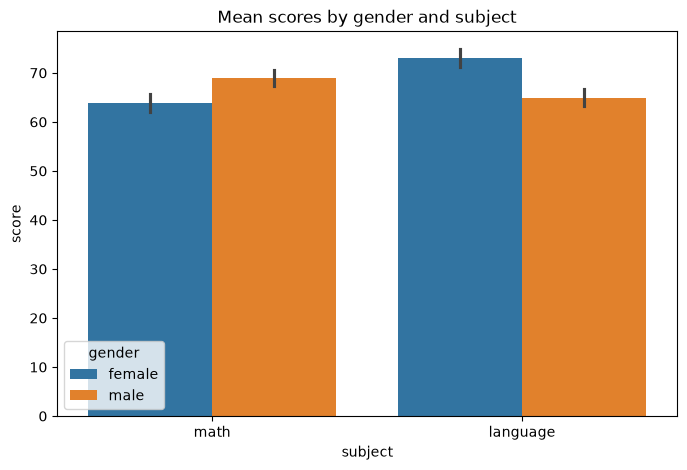

In [19]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="subject", y="score", hue="gender", estimator=np.mean)
plt.title("Mean scores by gender and subject")
plt.show()

The barplot shows mean score differences between male and female students across both subjects.

## 3.2 Comparison of Scores by Parental Education Level

This section analyzes whether a student's performance depends on the parental education level.

In [43]:
edu_summary = (
    df.groupby(['parental_level_of_education', 'subject'])['score']
      .agg(['count', 'mean', 'std', 'median'])
)

edu_summary

count       mean        std  median
parental_level_of_education subject                                      
associate's degree          language    177  70.022599  14.214951    72.0
                            math        177  67.813559  15.244382    66.0
bachelor's degree           language     94  72.058511  14.267200    73.0
                            math         94  68.436170  15.048708    67.0
high school                 language    156  63.532051  13.398685    65.0
                            math        156  62.243590  14.036989    63.0
master's degree             language     59  75.525424  13.554304    76.0
                            math         59  69.745763  15.153915    73.0

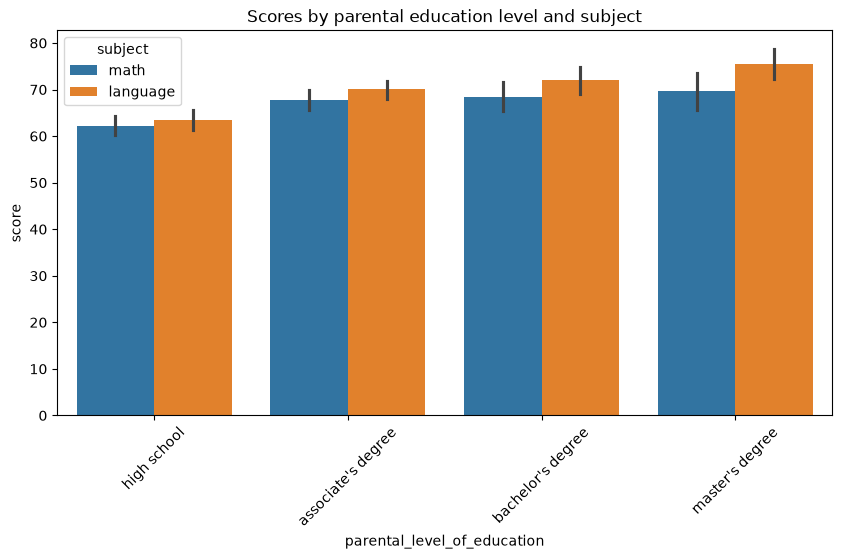

In [44]:
plt.figure(figsize=(10,5))
sns.barplot(data=df, x="parental_level_of_education", y="score", hue="subject", estimator=np.mean)
plt.xticks(rotation=45)
plt.title("Scores by parental education level and subject")
plt.show()

# 4. Research Hypotheses

This section formulates hypotheses about differences in performance between groups.

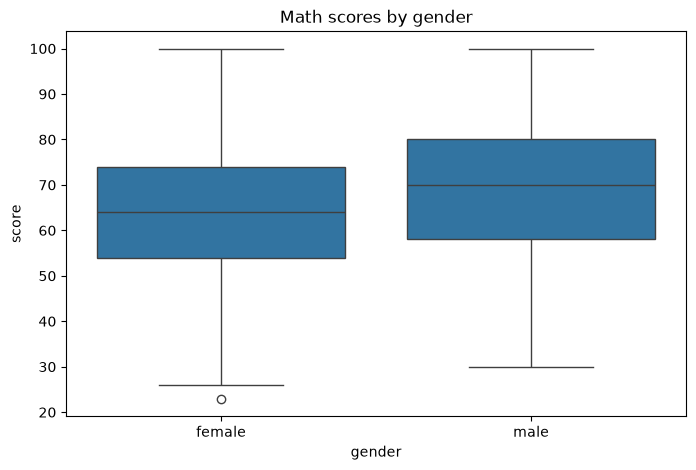

In [25]:
plt.figure(figsize=(8,5))
sns.boxplot(data=math_df, x='gender', y='score')
plt.title("Math scores by gender")
plt.show()

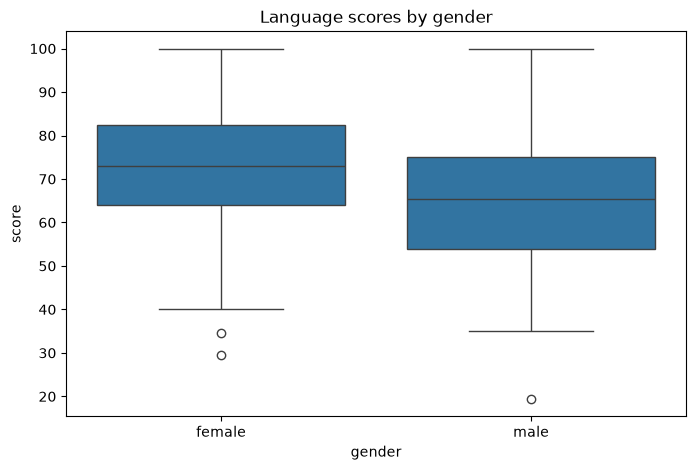

In [27]:
plt.figure(figsize=(8,5))
sns.boxplot(data=lang_df, x='gender', y='score')
plt.title("Language scores by gender")
plt.show()

## 4.1 Hypothesis About Gender

### Null hypothesis ($H_{0}$)
There is no difference in mean scores between boys and girls.

### Alternative hypothesis ($H_{1}$)
There is a difference in mean scores between boys and girls.


In [46]:
male_math = math_df[math_df['gender'] == 'male']['score']
female_math = math_df[math_df['gender'] == 'female']['score']

male_lang = lang_df[lang_df['gender'] == 'male']['score']
female_lang = lang_df[lang_df['gender'] == 'female']['score']


Maths T-test

In [48]:

stats.levene(male_math, female_math)

LeveneResult(statistic=np.float64(0.006027226933929371), pvalue=np.float64(0.938150311199935))

In [49]:
stats.ttest_ind(male_math, female_math, equal_var=False)

TtestResult(statistic=np.float64(3.7782415760861223), pvalue=np.float64(0.00017765367995423856), df=np.float64(483.2323215504577))

Language T-test

In [50]:
stats.levene(male_lang, female_lang)

LeveneResult(statistic=np.float64(0.15959812692149067), pvalue=np.float64(0.6897030079547449))

In [51]:
stats.ttest_ind(male_lang, female_lang, equal_var=False)

TtestResult(statistic=np.float64(-6.409643311669151), pvalue=np.float64(3.466762335140578e-10), df=np.float64(483.99755070317576))

## 4.2 Hypothesis About Parental Education

### Null hypothesis ($H_{0}$)
The mean scores across all parental education groups are equal.

### Alternative hypothesis ($H_{1}$)
At least one group has a different mean score.


In [29]:
df.groupby('parental_level_of_education')['score'].describe()

,count,mean,std,min,25%,50%,75%,max
parental_level_of_education,,,,,,,,
associate's degree,354.0,68.918079,14.759270,26.0,57.500,69.5,80.00,100.0
bachelor's degree,188.0,70.247340,14.736228,29.0,61.875,70.0,80.00,100.0
high school,312.0,62.887821,13.714659,19.5,53.375,64.0,72.00,99.5
master's degree,118.0,72.635593,14.606032,40.0,62.000,73.0,83.75,100.0


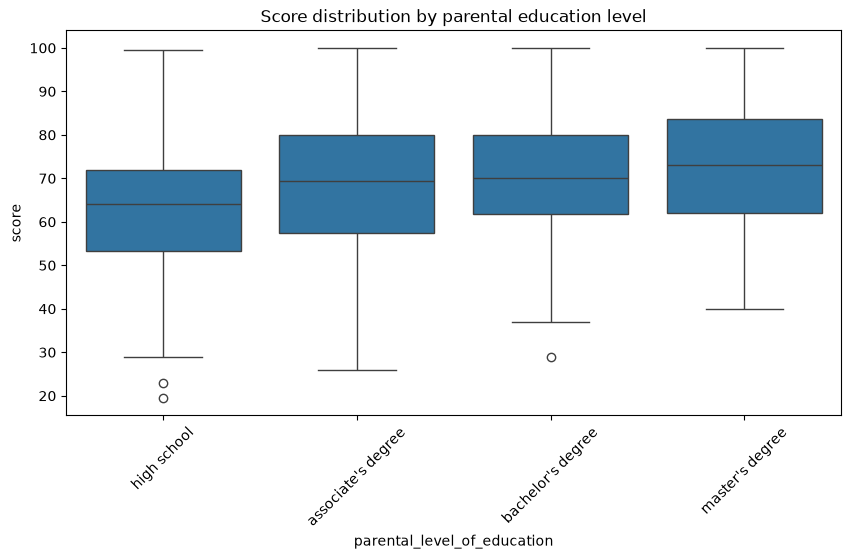

In [30]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='parental_level_of_education', y='score')
plt.xticks(rotation=45)
plt.title("Score distribution by parental education level")
plt.show()

The boxplot shows potential differences in score distributions across parental education levels.

In [31]:
groups = [group["score"].values for name, group in df.groupby("parental_level_of_education")]
stats.levene(*groups)

LeveneResult(statistic=np.float64(1.3148922354132464), pvalue=np.float64(0.268160743613251))

In [32]:
stats.f_oneway(*groups)

F_onewayResult(statistic=np.float64(19.01783467265518), pvalue=np.float64(5.466869914178441e-12))

In [ ]:
tukey = pairwise_tukeyhsd(
    endog=df['score'],
    groups=df['parental_level_of_education'],
    alpha=0.05
)

print(tukey)

            Multiple Comparison of Means - Tukey HSD, FWER=0.05            
      group1             group2      meandiff p-adj   lower   upper  reject
---------------------------------------------------------------------------
associate's degree bachelor's degree   1.3293 0.7364  -2.017  4.6755  False
associate's degree       high school  -6.0303    0.0 -8.9097 -3.1509   True
associate's degree   master's degree   3.7175 0.0727 -0.2241  7.6591  False
 bachelor's degree       high school  -7.3595    0.0 -10.783  -3.936   True
 bachelor's degree   master's degree   2.3883 0.4925 -1.9667  6.7432  False
       high school   master's degree   9.7478    0.0  5.7404 13.7551   True
---------------------------------------------------------------------------


# 5. Final Results

This section summarizes the key findings from the analysis and interprets the statistical test results.